In [1]:
import pandas as pd

#Load the dataset
#加载数据集
file_path = r'C:\Users\yuentolong\Dataset .csv'
df = pd.read_csv(file_path,encoding = 'latin-1')

#check the data
#检查数据
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [2]:
#Judge if the restaurant is a chain restaurant：there are more than two restaurants in different cities
#判断餐厅是否为连锁餐厅:在不同城市有两个以上的餐厅

#Group by restaurant,convert to nunique type and traverse each object 
#按照restaurant进行分组 转为nunique类型 并且对每个对象进行遍历
df_num_cities = df.groupby('Restaurant Name')['City'].transform('nunique')
df_Is_chain = df_num_cities.map(lambda x : 'Yes' if x >= 2 else 'No')

#print the result
#输出结果
print("Is chain restaurant:",df_Is_chain.value_counts()['Yes'])
print('Is not chain restaurant:',df_Is_chain.value_counts()['No'])

Is chain restaurant: 1863
Is not chain restaurant: 7688


In [24]:
#print top10 chain restaurant
#输出top10连锁餐厅
df_is_chain = df[df_Is_chain == 'Yes']['Restaurant Name'].value_counts()
print(df_is_chain.head(10))

Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: Restaurant Name, dtype: int64


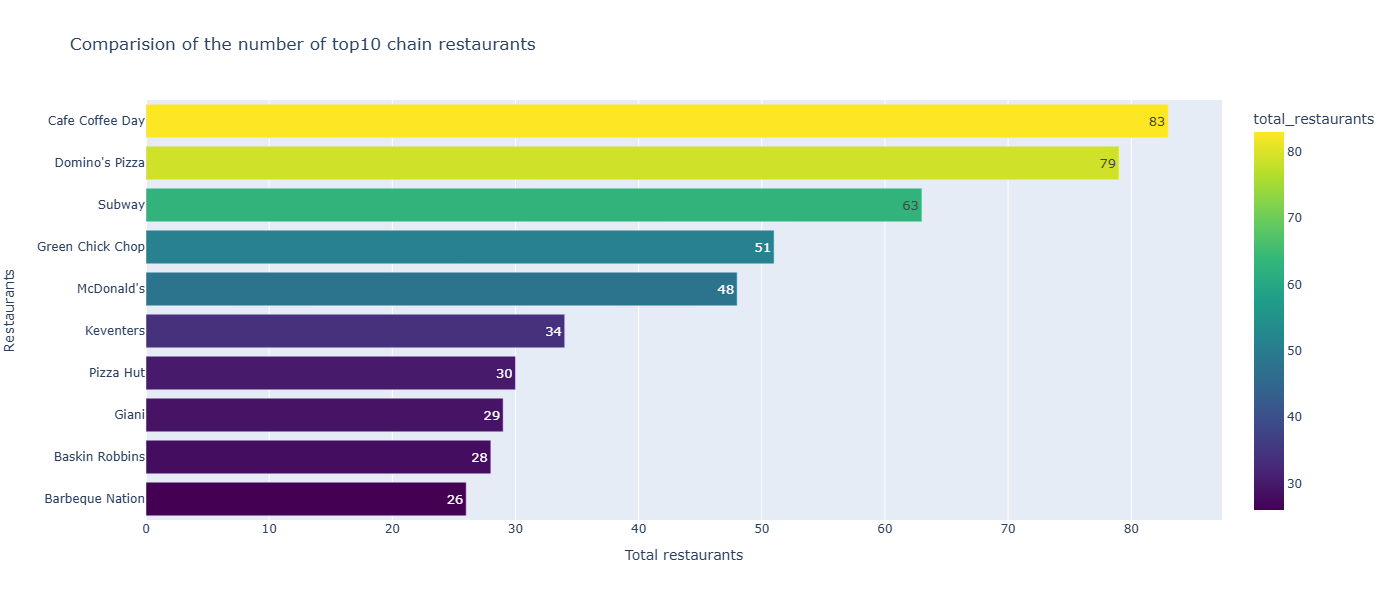

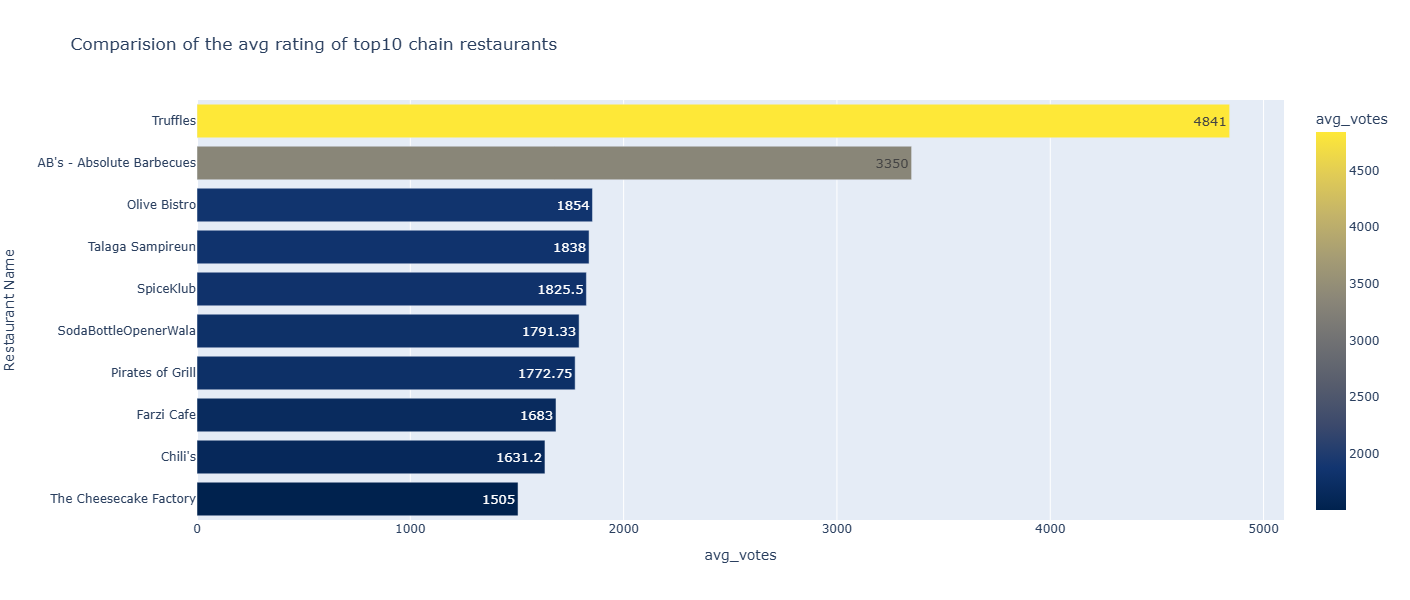

In [25]:
#Compare the number and avg_votes of top10 chain restaurants
#比较top10连锁餐厅的数目和平均投票数
Is_chain = df[df_Is_chain == 'Yes']

top10_chain_restaurant = Is_chain.groupby('Restaurant Name').agg(
    avg_votes = ('Votes','mean'),
    total_restaurants = ('Restaurant ID','count')
).round(2)

import plotly.express as px

fig1 = px.bar(
    top10_chain_restaurant.nlargest(10,'total_restaurants').reset_index(),
    x = 'total_restaurants',
    y = 'Restaurant Name',
    title = 'Comparision of the number of top10 chain restaurants',
    text = 'total_restaurants',
    color = 'total_restaurants',
    color_continuous_scale = 'Viridis'
)

fig1.update_traces(textposition = 'auto',textfont_size = 13)
fig1.update_layout(
    height = 600,
    width = 1200,
    xaxis_title = 'Total restaurants',
    yaxis_title = 'Restaurants',
    yaxis = {'categoryorder' : 'total ascending'}
)

fig1.show()

fig2 = px.bar(
    top10_chain_restaurant.nlargest(10,'avg_votes').reset_index(),
    x = 'avg_votes',
    y = 'Restaurant Name',
    title = 'Comparision of the avg rating of top10 chain restaurants',
    text = 'avg_votes',
    color = 'avg_votes',
    color_continuous_scale = 'cividis'
)

fig2.update_traces(textposition = 'auto',textfont_size = 13)
fig2.update_layout(
    width = 1200,
    height = 600,
    yaxis = {'categoryorder' : 'total ascending'}
)

fig2.show()

In [23]:
#Compare the avg_rating and avg_votes of chain and non-chain restaurants
# 比较连锁和非连锁的餐厅的平均评分和平均票数
analysis_chain = df.groupby(df_Is_chain).agg(
    total_restaurants = ('Restaurant Name','count'),
    avg_rating = ('Aggregate rating','mean'),
    avg_votes = ('Votes','mean'),
    total_votes = ('Votes','sum')
).round(2)

analysis_chain.index.name = 'is_chain'

print(analysis_chain.reset_index())

  is_chain  total_restaurants  avg_rating  avg_votes  total_votes
0       No               7688        2.62     148.37      1140639
1      Yes               1863        2.86     192.17       358006


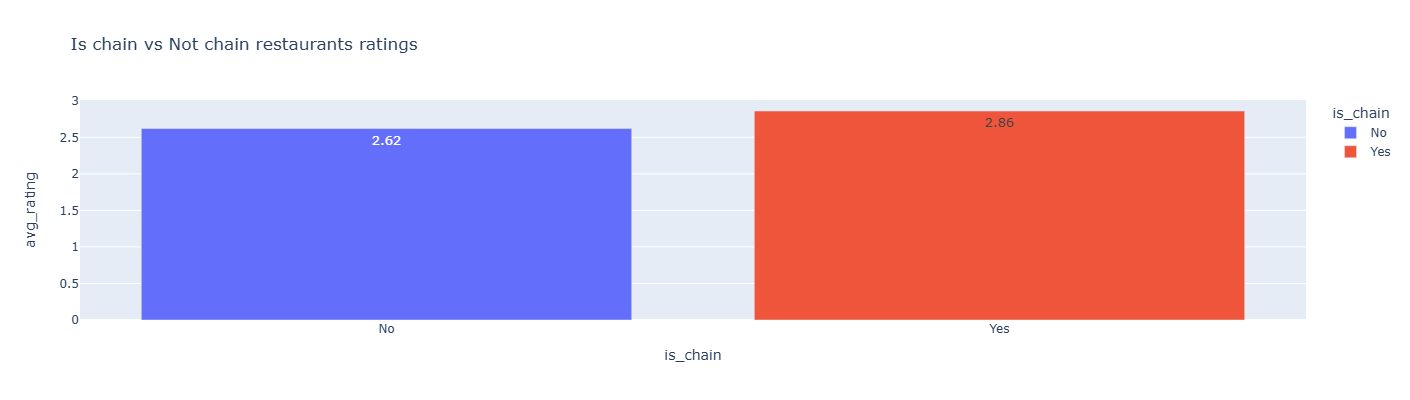

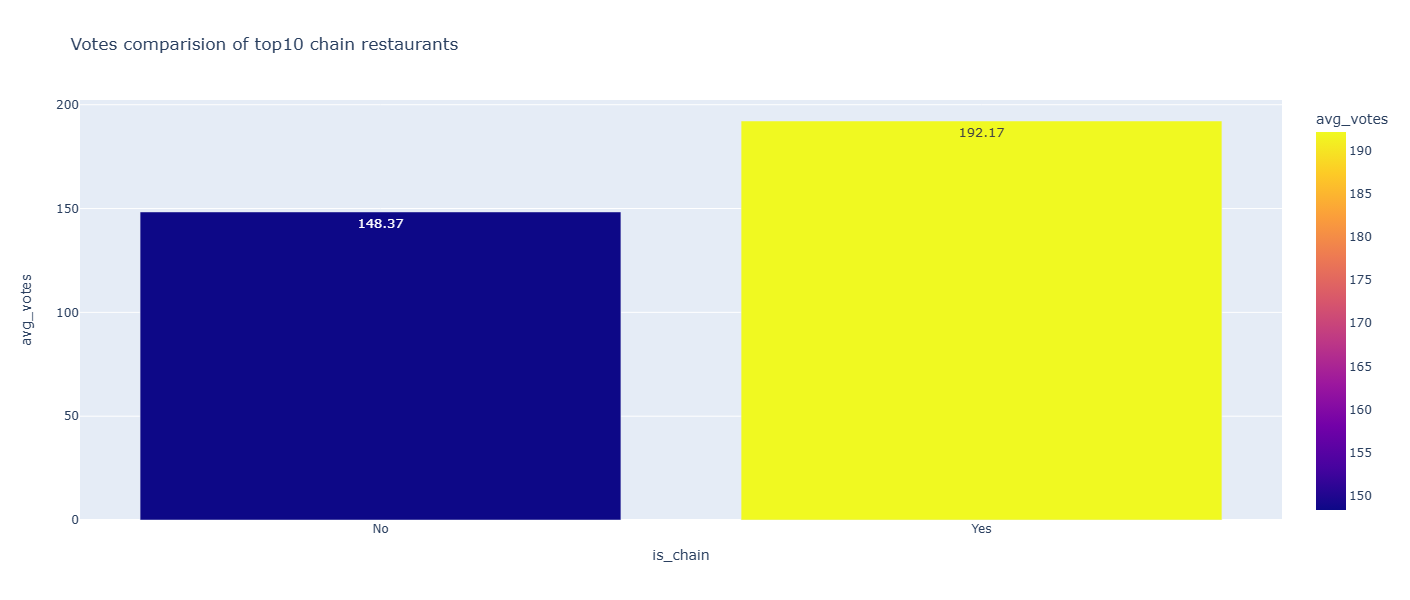

In [6]:
#Visualization for it
#可视化
fig3 = px.bar(
    analysis_chain.reset_index(),
    x = 'is_chain',
    y = 'avg_rating',
    title = 'Is chain vs Not chain restaurants ratings',
    text = 'avg_rating',
    color = 'is_chain'
    
)

fig3.update_traces(textposition = 'auto',textfont_size = 13)
fig3.update_layout(
    width = 600,
    height = 400
)
fig3.show()

fig4 = px.bar(
    analysis_chain.reset_index(),
    x = 'is_chain',
    y = 'avg_votes',
    text = 'avg_votes',
    title = 'Votes comparision of top10 chain restaurants',
    color = 'avg_votes'
)

fig4.update_traces(textposition = 'auto',textfont_size = 13)
fig4.update_layout(
    height = 600,
    width = 600
)

fig4.show()